# Preprocessing pipeline

**Goal** here is to select a proper window of samples.

Apply **filtering** within the window to interpolate data during blinks

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

COLET_DATASET_DIR = Path("../datasets/COLET_CSV")
EXP_SELECT = "participant_01/Task_1"

In [3]:
# Load the different daat from eye tracker
gaze_df = pd.read_csv(COLET_DATASET_DIR / EXP_SELECT / "gaze.csv")
pupil_df = pd.read_csv(COLET_DATASET_DIR / EXP_SELECT / "pupil.csv")
blink_df = pd.read_csv(COLET_DATASET_DIR / EXP_SELECT / "blinks.csv")

print(f"Loaded {gaze_df.shape[0]} gaze records.")
print(f"Loaded {pupil_df.shape[0]} pupil records.")
print(f"Loaded {blink_df.shape[0]} blink records.")

Loaded 8205 gaze records.
Loaded 16406 pupil records.
Loaded 2 blink records.


In [29]:
# Sort pupil data by choosing best confidence for each timestamp for each eye
pupil_df_best = pupil_df.groupby(['pupil_timestamp', 'eye_id'], as_index=False).apply(lambda x: x.loc[x['confidence'].idxmax()])
pupil_df_best.reset_index(drop=True, inplace=True)
pupil_df_best.drop(columns=['norm_pos_x', 'norm_pos_y'], inplace=True)
pupil_df_best.rename(columns={'diameter': 'pupil_diameter_mm', 'confidence': 'pupil_confidence'}, inplace=True)
pupil_df_best.head()

,pupil_timestamp,eye_id,pupil_confidence,pupil_diameter_mm,ellipse_center_x,ellipse_center_y,ellipse_axis_a,ellipse_axis_b
0,5410.553797,1,1.0,40.757561,77.991356,55.965595,25.383852,40.757561
1,5410.557872,0,1.0,38.723305,62.588215,115.951805,23.741541,38.723305
2,5410.561675,1,1.0,40.842903,77.960808,56.072765,25.485304,40.842903
3,5410.565491,0,1.0,39.237560,62.568382,115.802177,23.588182,39.237560
4,5410.571092,1,1.0,40.950336,77.953743,56.054668,25.205196,40.950336


In [30]:
# Merge gaze and pupil data on closest timestamp match
merged_df = pd.merge_asof(gaze_df.sort_values('gaze_timestamp'),
                          pupil_df_best.sort_values('pupil_timestamp'),
                          left_on='gaze_timestamp',
                          right_on='pupil_timestamp',
                          direction='nearest',
                          tolerance=1.0/240*2)  # tolerance in ms
print(f"There are {merged_df[merged_df.pupil_confidence.isna()].index.size} non matching timestamp within the limits")
# Since only one value, drop the row
merged_df_clean = merged_df.dropna()
# Let's reindex the dataframe using timestamp starting from 0 adn dropping the original timestamp columns
merged_df_clean['timestamp_sec'] = merged_df_clean['gaze_timestamp'] - merged_df_clean['gaze_timestamp'].min()
merged_df_clean.drop(columns=['gaze_timestamp', 'pupil_timestamp'], inplace=True)
print(f"After merging, we have {merged_df_clean.shape[0]} records with both gaze and pupil data.")
fs = merged_df_clean.shape[0] / (merged_df_clean['timestamp_sec'].max()) 
print("With an average frequency of {:.2f} Hz".format(fs))
merged_df_clean.head()

There are 1 non matching timestamp within the limits
After merging, we have 8204 records with both gaze and pupil data.
With an average frequency of 242.68 Hz


,confidence,norm_pos_x,norm_pos_y,gaze_point_3d_x,gaze_point_3d_y,gaze_point_3d_z,eye_id,pupil_confidence,pupil_diameter_mm,ellipse_center_x,ellipse_center_y,ellipse_axis_a,ellipse_axis_b,timestamp_sec
0,0.999499,0.446264,0.846886,-6.720630,-31.252881,80.700682,1.0,1.0,40.757561,77.991356,55.965595,25.383852,40.757561,0.000000
1,0.999653,0.446534,0.847007,-6.690706,-31.298388,80.793260,1.0,1.0,40.757561,77.991356,55.965595,25.383852,40.757561,0.004120
2,0.999648,0.446660,0.846410,-6.664575,-31.211650,80.708374,0.0,1.0,38.723305,62.588215,115.951805,23.741541,38.723305,0.008059
3,0.999656,0.446442,0.845542,-6.689463,-31.118351,80.664979,1.0,1.0,40.842903,77.960808,56.072765,25.485304,40.842903,0.011868
4,0.999565,0.446472,0.845614,-6.683464,-31.115105,80.640260,0.0,1.0,39.237560,62.568382,115.802177,23.588182,39.237560,0.016577


## A. Extract window

Extract a proper window for analysis.

*A priori* using $T=5s$ consisting of $N\approx 300$ samples seems like a good start.

Thus, inference could be done on a *per second* basis, giving overlapping windows of N~240 samples

In [31]:
N = 300 # Number of samples in the window
offset = 0 # Offset in # samples for the start of the window

print("Extracting a window of {} samples which corresponds to {:.2f} seconds".format(N, N/fs))
window_df = merged_df_clean.iloc[offset:offset+N].copy()

Extracting a window of 300 samples which corresponds to 1.24 seconds


No (official) blinks detected in the current window.


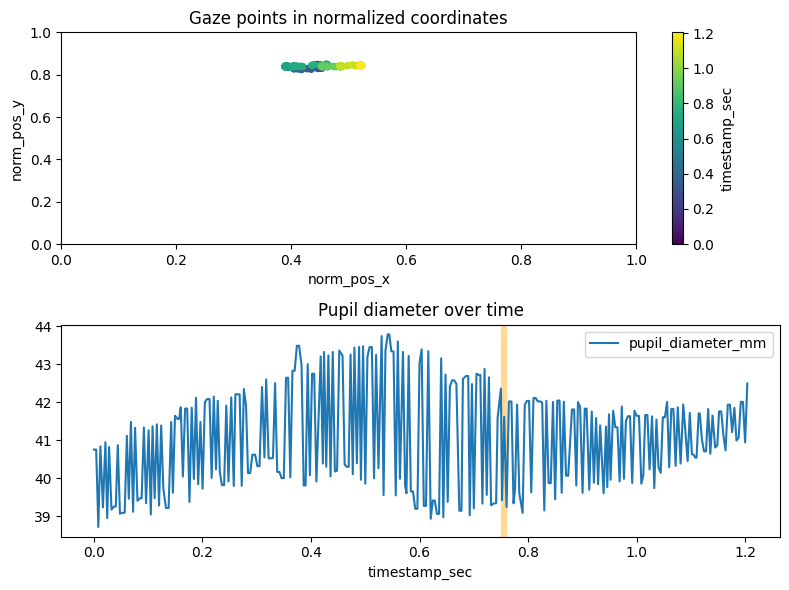

In [55]:
import matplotlib
# Visualize a bit the data in the window
fig = plt.figure(figsize=(8, 6), tight_layout=True)
ax0 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2)
# Plot gaze data in normalized coordinates
colormap = matplotlib.colormaps['viridis']
ax0.set_xlim(0, 1)
ax0.set_ylim(0, 1)
window_df.plot("norm_pos_x", "norm_pos_y", kind='scatter', c='timestamp_sec', colormap=colormap, title="Gaze points in normalized coordinates", ax=ax0)

# Plot (best of the 2 eyes) pupil diameter over time 
window_df.plot("timestamp_sec", "pupil_diameter_mm", kind='line', title="Pupil diameter over time", ax=ax2)

# Overlay the blinks as vertical zones
blink_df['blink_timestamp'] = blink_df['start_timestamp'] - window_df['timestamp_sec'].min() # Align blink timestamps with window timestamps
blink_df_window = blink_df[(blink_df['blink_timestamp'] >= window_df['timestamp_sec'].min()) & (blink_df['blink_timestamp'] <= window_df['timestamp_sec'].max())]
if blink_df_window.empty:
    print("No (official) blinks detected in the current window.")
for _, row in blink_df_window.iterrows():
    ax2.axvspan(row['timestamp'], row['timestamp'] + row['duration'], color='red', alpha=0.3)

# Show low confidence zones
window_df['low_confidence'] = window_df['pupil_confidence'] < 0.95
for _, row in window_df[window_df.low_confidence].iterrows():
    ax2.axvspan(row['timestamp_sec'], row['timestamp_sec'] + 1.0/240, color='orange', alpha=0.3)

In [62]:
def compute_angular_data(df):
    gaze_angular_data = df[['timestamp_sec', 'gaze_point_3d_x', 'gaze_point_3d_y', 'gaze_point_3d_z']].copy()
    gaze_angular_data['prev_gaze_point_3d_x'] = gaze_angular_data['gaze_point_3d_x'].shift(1)
    gaze_angular_data['prev_gaze_point_3d_y'] = gaze_angular_data['gaze_point_3d_y'].shift(1)
    gaze_angular_data['prev_gaze_point_3d_z'] = gaze_angular_data['gaze_point_3d_z'].shift(1)
    gaze_angular_data.drop(index=0, inplace=True)  # Drop the first row which has NaN values

    def calculate_angle(row):
        v1 = np.array([row['gaze_point_3d_x'], row['gaze_point_3d_y'], row['gaze_point_3d_z']])
        v2 = np.array([row['prev_gaze_point_3d_x'], row['prev_gaze_point_3d_y'], row['prev_gaze_point_3d_z']])
        dot_product = np.dot(v1, v2)
        norm_v1 = np.linalg.norm(v1)
        norm_v2 = np.linalg.norm(v2)
        if norm_v1 == 0 or norm_v2 == 0:
            return 0.0
        cos_theta = dot_product / (norm_v1 * norm_v2)
        cos_theta = np.clip(cos_theta, -1.0, 1.0)  # Clip to avoid numerical issues
        angle_rad = np.arccos(cos_theta)
        angle_deg = np.degrees(angle_rad)
        return angle_deg

    df['gaze_angle_delta_deg'] = gaze_angular_data.apply(calculate_angle, axis=1)
    return df

In [ ]:
# Calculate gaze angle and add it to the dataframe
window_with_angular_df = compute_angular_data(window_df)
window_with_angular_df.head()

,confidence,norm_pos_x,norm_pos_y,gaze_point_3d_x,gaze_point_3d_y,gaze_point_3d_z,eye_id,pupil_confidence,pupil_diameter_mm,ellipse_center_x,ellipse_center_y,ellipse_axis_a,ellipse_axis_b,timestamp_sec,low_confidence,gaze_angle_delta_deg
0,0.999499,0.446264,0.846886,-6.720630,-31.252881,80.700682,1.0,1.0,40.757561,77.991356,55.965595,25.383852,40.757561,0.000000,False,NaN
1,0.999653,0.446534,0.847007,-6.690706,-31.298388,80.793260,1.0,1.0,40.757561,77.991356,55.965595,25.383852,40.757561,0.004120,False,0.025613
2,0.999648,0.446660,0.846410,-6.664575,-31.211650,80.708374,0.0,1.0,38.723305,62.588215,115.951805,23.741541,38.723305,0.008059,False,0.035117
3,0.999656,0.446442,0.845542,-6.689463,-31.118351,80.664979,1.0,1.0,40.842903,77.960808,56.072765,25.485304,40.842903,0.011868,False,0.051281
4,0.999565,0.446472,0.845614,-6.683464,-31.115105,80.640260,0.0,1.0,39.237560,62.568382,115.802177,23.588182,39.237560,0.016577,False,0.004736
